# Bruun Rule Validation (1980-2000 Training, 2000-2024 Validation)

This notebook evaluates which Bruun-rule equation best reproduces NZCCD shoreline change,
by training the pure Bruun-rule prediction (`R_bruun * SLR`, no fitted/free parameters) on
1980-2000 and validating it on 2000-2024, against the real observed shoreline change.

Assumptions used here:
- Ground truth for both periods is the real NZCCD dated shoreline data: a linear-regression
  trend fit to the individual dated intersection points on each side of 2000 (section 2b),
  not derived from a Bruun equation.
- The prediction for both periods is `R_bruun * SLR forcing` only - no historic-trend
  extrapolation is added on top (an earlier version of this notebook added a historic-trend
  term for the validation period, which double-counted SLR-driven retreat since the real
  pre-2000 trend already reflects past SLR effects; that has been removed).
- SLR forcing: PSMSL nearest-gauge 1980-2000 trend for training; 2020 medium-confidence
  `NZSeaRise_proj_novlm.csv` value for validation.
- `R_bruun`/`CD`/`B` are treated as time-invariant across both periods (2016 DEM, national
  D50, full-record WHACS-derived CD) - see the markdown note in section 3.

Data sources:
- Historical shoreline positions: `slpoints_rates.csv.gz`
- Equation-specific Bruun parameters: `output/doc_eq/NZ_*_{hallin|hallout|birk}.csv`
- SLR values: `NZSeaRise_proj_novlm.csv`, `preprocess2_pre2000SLR.py` output

This workflow is separate from `step4_bruunrule.py` and does not modify the original pipeline.

## 1. Set Up Environment and Imports

In [1]:
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "output" / "validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CUTOFF = pd.Timestamp("2000-12-31")
VALIDATION_TARGET = pd.Timestamp("2024-12-31")
TRAIN_FRACTION = 0.7

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("TRAIN_CUTOFF:", TRAIN_CUTOFF.date())
print("VALIDATION_TARGET:", VALIDATION_TARGET.date())

PROJECT_ROOT: /mnt/Bruunrule_Yaxiong/code
OUTPUT_DIR: /mnt/Bruunrule_Yaxiong/code/output/validation
TRAIN_CUTOFF: 2000-12-31
VALIDATION_TARGET: 2024-12-31


## 2. Load Historical Shoreline Positions and Build Pre/Post-2000 Targets

In [2]:
slpoints_path = PROJECT_ROOT / "slpoints_rates.csv.gz"
if not slpoints_path.exists():
    raise FileNotFoundError(f"Missing required file: {slpoints_path}")

sl = pd.read_csv(slpoints_path, low_memory=False)

required_cols = ["Unique_ID", "Date", "IntersectX", "IntersectY"]
missing = [c for c in required_cols if c not in sl.columns]
if missing:
    raise KeyError(f"Missing required columns in slpoints file: {missing}")

sl = sl.copy()
sl["Unique_ID"] = pd.to_numeric(sl["Unique_ID"], errors="coerce").astype("Int64")
sl["Date_dt"] = pd.to_datetime(sl["Date"], errors="coerce", dayfirst=True)
sl["IntersectX"] = pd.to_numeric(sl["IntersectX"], errors="coerce")
sl["IntersectY"] = pd.to_numeric(sl["IntersectY"], errors="coerce")
sl = sl.dropna(subset=["Unique_ID", "Date_dt", "IntersectX", "IntersectY"]).copy()

# Keep one point per transect-date to avoid duplicate-date ambiguity
sl = sl.sort_values(["Unique_ID", "Date_dt"]).drop_duplicates(subset=["Unique_ID", "Date_dt"], keep="last")

first_pts = sl.sort_values("Date_dt").groupby("Unique_ID", as_index=False).first()
pre2000_pts = (
    sl[sl["Date_dt"] <= TRAIN_CUTOFF]
    .sort_values("Date_dt")
    .groupby("Unique_ID", as_index=False)
    .last()
)
latest_to_2024_pts = (
    sl[sl["Date_dt"] <= VALIDATION_TARGET]
    .sort_values("Date_dt")
    .groupby("Unique_ID", as_index=False)
    .last()
)

obs = (
    first_pts[["Unique_ID", "Date_dt", "IntersectX", "IntersectY"]]
    .rename(columns={"Date_dt": "first_date", "IntersectX": "first_x", "IntersectY": "first_y"})
    .merge(
        pre2000_pts[["Unique_ID", "Date_dt", "IntersectX", "IntersectY"]].rename(
            columns={"Date_dt": "pre2000_date", "IntersectX": "pre2000_x", "IntersectY": "pre2000_y"}
        ),
        on="Unique_ID",
        how="inner",
    )
    .merge(
        latest_to_2024_pts[["Unique_ID", "Date_dt", "IntersectX", "IntersectY"]].rename(
            columns={"Date_dt": "latest_date", "IntersectX": "latest_x", "IntersectY": "latest_y"}
        ),
        on="Unique_ID",
        how="inner",
    )
)

# Use a stable landward positive axis from first -> latest(<=2024)
obs["ux_obs"] = obs["latest_x"] - obs["first_x"]
obs["uy_obs"] = obs["latest_y"] - obs["first_y"]
obs["u_norm"] = np.hypot(obs["ux_obs"], obs["uy_obs"])
obs = obs[obs["u_norm"] > 0].copy()
obs["ux_obs"] = obs["ux_obs"] / obs["u_norm"]
obs["uy_obs"] = obs["uy_obs"] / obs["u_norm"]

# Signed projected distances along the transect axis
obs["obs_train_m"] = (obs["pre2000_x"] - obs["first_x"]) * obs["ux_obs"] + (obs["pre2000_y"] - obs["first_y"]) * obs["uy_obs"]
obs["obs_valid_m"] = (obs["latest_x"] - obs["pre2000_x"]) * obs["ux_obs"] + (obs["latest_y"] - obs["pre2000_y"]) * obs["uy_obs"]
obs["obs_total_m"] = (obs["latest_x"] - obs["first_x"]) * obs["ux_obs"] + (obs["latest_y"] - obs["first_y"]) * obs["uy_obs"]

obs["train_years"] = (obs["pre2000_date"] - obs["first_date"]).dt.days / 365.25
obs["valid_years"] = (obs["latest_date"] - obs["pre2000_date"]).dt.days / 365.25

obs = obs[(obs["train_years"] > 0) & (obs["valid_years"] >= 0)].copy()

print("Historical shoreline rows:", len(sl))
print("Transects with full first/pre2000/latest windows:", len(obs))
obs[["Unique_ID", "first_date", "pre2000_date", "latest_date", "obs_train_m", "obs_valid_m"]].head()

Historical shoreline rows: 1581901
Transects with full first/pre2000/latest windows: 211407


,Unique_ID,first_date,pre2000_date,latest_date,obs_train_m,obs_valid_m
0,100000185990,1947-05-26,1971-02-11,2015-11-07,3.082929,8.614680
1,100000186642,1947-05-26,1971-02-11,2015-11-07,3.572714,6.808497
2,100000186861,1947-05-26,1971-02-11,2015-11-07,6.862956,7.922867
3,100000207668,1947-05-26,1971-02-11,2015-11-07,-3.101666,5.918942
4,100000208692,1947-05-26,1971-02-11,2015-11-07,-1.845909,5.694613


### 2b. Real Pre-2000 and Post-2000 Historic Trends from Individual Dated Shoreline Points

NZCCD's own `WLR`/`NSM`/`Duration` columns are a single whole-record rate (same value repeated
for every dated row of a transect) — they can't be split at 2000. But `slpoints_rates.csv.gz`
does carry the individual dated intersection points behind that rate (avg ~7 dates per
transect, up to 21), spanning both sides of 2000 for most transects. We use those directly to
fit our own linear-regression trend (m/yr) separately for the pre-2000 and post-2000 points,
along the same transect axis used elsewhere in this notebook.

In [10]:
# Project every individual dated point (not just first/pre2000/latest) onto each
# transect's observed axis, then fit an OLS trend (m/yr) separately for points
# dated <=2000 and points dated >2000. Vectorized (grouped sums) to stay fast
# across ~200k+ transects instead of a per-group polyfit call.
axis_cols = obs[["Unique_ID", "first_x", "first_y", "ux_obs", "uy_obs"]]
sl_ax = sl.merge(axis_cols, on="Unique_ID", how="inner").dropna(subset=["Date_dt"]).copy()
sl_ax["proj_m"] = (
    (sl_ax["IntersectX"] - sl_ax["first_x"]) * sl_ax["ux_obs"]
    + (sl_ax["IntersectY"] - sl_ax["first_y"]) * sl_ax["uy_obs"]
)
sl_ax["year_dec"] = sl_ax["Date_dt"].dt.year + (sl_ax["Date_dt"].dt.dayofyear - 1) / 365.25

MIN_PTS_FOR_TREND = 3

def period_trend_fast(df, rate_col, n_col):
    tmp = df.copy()
    tmp["xy"] = tmp["year_dec"] * tmp["proj_m"]
    tmp["xx"] = tmp["year_dec"] ** 2
    agg = tmp.groupby("Unique_ID").agg(
        n=("year_dec", "size"),
        sx=("year_dec", "sum"),
        sy=("proj_m", "sum"),
        sxy=("xy", "sum"),
        sxx=("xx", "sum"),
    )
    denom = agg["n"] * agg["sxx"] - agg["sx"] ** 2
    slope = np.where(
        (agg["n"] >= MIN_PTS_FOR_TREND) & (denom != 0),
        (agg["n"] * agg["sxy"] - agg["sx"] * agg["sy"]) / denom,
        np.nan,
    )
    out = pd.DataFrame({rate_col: slope, n_col: agg["n"].to_numpy()}, index=agg.index).reset_index()
    return out

pre2000_trend = period_trend_fast(
    sl_ax[sl_ax["year_dec"] <= 2000], "obs_rate_pre2000_m_per_yr", "n_pts_pre2000"
)
post2000_trend = period_trend_fast(
    sl_ax[sl_ax["year_dec"] > 2000], "obs_rate_post2000_m_per_yr", "n_pts_post2000"
)

obs = obs.merge(pre2000_trend, on="Unique_ID", how="left").merge(post2000_trend, on="Unique_ID", how="left")

print("Transects with a fittable pre-2000 trend (>=3 dated points):", obs["obs_rate_pre2000_m_per_yr"].notna().sum())
print("Transects with a fittable post-2000 trend (>=3 dated points):", obs["obs_rate_post2000_m_per_yr"].notna().sum())
obs[["Unique_ID", "n_pts_pre2000", "obs_rate_pre2000_m_per_yr", "n_pts_post2000", "obs_rate_post2000_m_per_yr"]].head()

Transects with a fittable pre-2000 trend (>=3 dated points): 165259
Transects with a fittable post-2000 trend (>=3 dated points): 115103


,Unique_ID,n_pts_pre2000,obs_rate_pre2000_m_per_yr,n_pts_post2000,obs_rate_post2000_m_per_yr
0,100000185990,2,NaN,1.0,NaN
1,100000186642,2,NaN,1.0,NaN
2,100000186861,2,NaN,1.0,NaN
3,100000207668,2,NaN,1.0,NaN
4,100000208692,2,NaN,1.0,NaN


## 3. Load Equation Parameters from doc_eq and Current SLR (2020 Medium Confidence)

In [11]:
# Load equation-specific Bruun parameters from output/doc_eq
# Files contain hallin/hallout/birk variants; *_toe.csv is excluded here.
doc_eq_dir = PROJECT_ROOT / "output" / "doc_eq"
if not doc_eq_dir.exists():
    raise FileNotFoundError(f"Missing directory: {doc_eq_dir}")

eq_suffixes = ["hallin", "hallout", "birk"]

def pick_doc_eq_file(eq):
    candidates = sorted(glob.glob(str(doc_eq_dir / f"NZ_*_{eq}.csv")))
    # Exclude toe variants and keep one representative file (parameters are geometry-driven and expected invariant).
    candidates = [c for c in candidates if not c.lower().endswith("_toe.csv")]
    return candidates[0] if candidates else None

frames = []
for eq in eq_suffixes:
    fp = pick_doc_eq_file(eq)
    if fp is None:
        print(f"WARNING: no doc_eq CSV found for equation={eq}")
        continue

    cols = ["Unique_ID", "Site ID", "R_bruun", "L", "B", "CD", "ux1", "uy1", "point_X", "point_Y"]
    df = pd.read_csv(fp, usecols=cols)
    df["Unique_ID"] = pd.to_numeric(df["Unique_ID"], errors="coerce").astype("Int64")
    df["Site ID"] = pd.to_numeric(df["Site ID"], errors="coerce").astype("Int64")
    for c in ["R_bruun", "L", "B", "CD", "ux1", "uy1", "point_X", "point_Y"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["Unique_ID", "Site ID", "R_bruun"]).copy()
    df["equation"] = eq
    df["source_file"] = Path(fp).name
    df = df.drop_duplicates(subset=["Unique_ID"], keep="first")
    frames.append(df)

if not frames:
    raise ValueError("No usable equation files found in output/doc_eq.")

bruun = pd.concat(frames, ignore_index=True)

# Note: R_bruun/CD/B are geometry- and wave-climate-driven (2016 LiDAR/bathymetry DEM
# for B, national-constant D50 for hallout, full-record 1979-2024 WHACS-derived CD).
# They are treated as time-invariant and reused as-is for both the 1980-2000 training
# window and the 2000-2024 validation window; only the SLR forcing term differs by
# period below. This matches how Hallermeier/Birkemeier CD is normally applied
# (a representative/quasi-stationary wave climate), and avoids the multi-hour national
# pipeline rerun that would be needed to derive a 1980-2000-only WHACS CD per equation.

# 2020 medium-confidence SLR from NZSeaRise as the 'current' (validation-period) SLR term.
# Note: NZSeaRise file in this workspace starts at 2020 (no 2000/2024 rows).
nzslr_path = PROJECT_ROOT / "NZSeaRise_proj_novlm.csv"
if not nzslr_path.exists():
    raise FileNotFoundError(f"Missing NZSeaRise file: {nzslr_path}")

nz = pd.read_csv(nzslr_path)
req_slr_cols = ["Confidence", "site", "year", "0.5"]
missing_slr = [c for c in req_slr_cols if c not in nz.columns]
if missing_slr:
    raise KeyError(f"Missing NZSeaRise columns: {missing_slr}")

nz["site"] = pd.to_numeric(nz["site"], errors="coerce").astype("Int64")
nz["year"] = pd.to_numeric(nz["year"], errors="coerce")
nz["0.5"] = pd.to_numeric(nz["0.5"], errors="coerce")

slr2020 = (
    nz[(nz["Confidence"] == "medium_confidence") & (nz["year"] == 2020)]
    .groupby("site", as_index=False)["0.5"]
    .median()
    .rename(columns={"site": "Site ID", "0.5": "slr_2020_m"})
)

bruun = bruun.merge(slr2020, on="Site ID", how="left")

# 1980-2000 SLR (training-period term) from nearest PSMSL NZ tide-gauge trend,
# produced by preprocess2_pre2000SLR.py. Both terms are kept VLM-agnostic/consistent
# for now (see /memories/repo/bruun_validation_slr.md) - novlm NZSeaRise for 2000+,
# raw (relative) PSMSL trends for 1980-2000.
pre2000_slr_path = OUTPUT_DIR / "pre2000_slr_by_transect.csv"
if not pre2000_slr_path.exists():
    raise FileNotFoundError(
        f"Missing {pre2000_slr_path}; run preprocess2_pre2000SLR.py first."
    )

pre2000_slr = pd.read_csv(
    pre2000_slr_path,
    usecols=["Unique_ID", "nearest_station_name", "distance_km", "slr_1980_2000_m"],
)
pre2000_slr["Unique_ID"] = pd.to_numeric(pre2000_slr["Unique_ID"], errors="coerce").astype("Int64")

bruun = bruun.merge(pre2000_slr, on="Unique_ID", how="left")

found_eqs = sorted(bruun["equation"].dropna().unique().tolist())
print("Bruun records:", len(bruun))
print("Equations found:", found_eqs)
print("SLR-2020 (validation) matched rows:", int(bruun["slr_2020_m"].notna().sum()), "/", len(bruun))
print("SLR-1980-2000 (training) matched rows:", int(bruun["slr_1980_2000_m"].notna().sum()), "/", len(bruun))
if len(found_eqs) < 3:
    print("WARNING: fewer than 3 equations loaded from output/doc_eq.")
bruun.head()

Bruun records: 576897
Equations found: ['birk', 'hallin', 'hallout']
SLR-2020 (validation) matched rows: 576897 / 576897
SLR-1980-2000 (training) matched rows: 576897 / 576897


,Unique_ID,CD,B,L,R_bruun,Site ID,point_X,point_Y,ux1,uy1,equation,source_file,slr_2020_m,nearest_station_name,distance_km,slr_1980_2000_m
0,200409446488,16.380001,10.0,1634.662585,61.965979,5440,5.613323e+06,-4.286012e+06,-0.750271,0.66113,hallin,NZ_medium_confidence_y2050_s1.9_p0.17_hallin.csv,0.06,LYTTELTON II,521.779917,-0.028155
1,200409447515,16.380001,10.0,1634.662585,61.965979,5440,5.613332e+06,-4.286006e+06,-0.750271,0.66113,hallin,NZ_medium_confidence_y2050_s1.9_p0.17_hallin.csv,0.06,LYTTELTON II,521.769947,-0.028155
2,200409448528,16.380001,10.0,1634.662585,61.965979,5440,5.613341e+06,-4.286000e+06,-0.750271,0.66113,hallin,NZ_medium_confidence_y2050_s1.9_p0.17_hallin.csv,0.06,LYTTELTON II,521.759975,-0.028155
3,200409449534,16.380001,10.0,1634.662585,61.965979,5440,5.613349e+06,-4.285993e+06,-0.750271,0.66113,hallin,NZ_medium_confidence_y2050_s1.9_p0.17_hallin.csv,0.06,LYTTELTON II,521.750382,-0.028155
4,200409450537,16.380001,10.0,1634.662585,61.965979,5440,5.613357e+06,-4.285986e+06,-0.750271,0.66113,hallin,NZ_medium_confidence_y2050_s1.9_p0.17_hallin.csv,0.06,LYTTELTON II,521.741062,-0.028155


**Assumptions shared between the 1980-2000 training window and the 2000-2024 validation window:**
- D50: single national constant (`D50_M` in `depthofclosure_settings.py`), unchanged by period.
- Elevation (B / berm / dune-crest): sampled from the current (2016) LiDAR/bathymetry DEM for both periods (dune/berm elevation treated as time-invariant, standard Bruun-rule simplification).
- Wave climate / CD: derived from the full 1979-2024 WHACS hindcast record (not re-derived per period). Recomputing CD from a 1980-2000-only WHACS subset would require rerunning `step2_H12handT12h.py` -> `step3_matchwgandshorelinepoints.py` -> `step4_bruunrule.py` for all 3 equations nationwide, a multi-hour pipeline rerun; this has been deferred (flag if you want it done).

Only the SLR forcing term differs by period: PSMSL nearest-gauge trend for 1980-2000 (training), `NZSeaRise_proj_novlm.csv` 2020 medium-confidence value for 2000-2024 (validation).

## 4. Bruun-Rule Prediction for 1980-2000 (Training) and 2000-2024 (Validation)

In [24]:
# Merge observed pre/post-2000 distances with equation parameters
data = bruun.merge(obs, on="Unique_ID", how="inner")

data = data.dropna(
    subset=["obs_train_m", "obs_valid_m", "train_years", "valid_years", "R_bruun", "slr_2020_m", "slr_1980_2000_m"]
).copy()

# Prefer the real multi-point regression trend (section 2b) as the observed ground
# truth; fall back to the plain two-point secant only where too few dated points
# exist to fit a regression.
data["obs_train_m_used"] = (
    data["obs_rate_pre2000_m_per_yr"].fillna(data["obs_train_m"] / data["train_years"]) * data["train_years"]
)
data["obs_valid_m_used"] = (
    data["obs_rate_post2000_m_per_yr"].fillna(data["obs_valid_m"] / data["valid_years"]) * data["valid_years"]
)

# --- Training (1980-2000): pure Bruun-rule prediction, no fitted/free parameters ---
# pred_train_m = R_bruun (geometry/CD sensitivity, time-invariant) * SLR forcing over 1980-2000
# (PSMSL nearest-gauge trend). Compared against the real (regression-based) observed retreat.
data["pred_train_m"] = data["R_bruun"] * data["slr_1980_2000_m"]
data["resid_train_m"] = data["pred_train_m"] - data["obs_train_m_used"]

# --- Validation (2000-2024): pure Bruun-rule prediction, same style as training ---
# pred_valid_m = R_bruun * SLR forcing (NZSeaRise novlm, 2020 medium confidence). No
# historic-trend term is added on top - that would double-count SLR-driven retreat,
# since the real pre-2000 trend already reflects whatever SLR was doing historically.
data["pred_valid_m"] = data["R_bruun"] * data["slr_2020_m"]

# Position projection along observed transect axis
data["pred_latest_x"] = data["pre2000_x"] + data["ux_obs"] * data["pred_valid_m"]
data["pred_latest_y"] = data["pre2000_y"] + data["uy_obs"] * data["pred_valid_m"]
data["xy_err_m"] = np.hypot(data["pred_latest_x"] - data["latest_x"], data["pred_latest_y"] - data["latest_y"])

data["resid_valid_m"] = data["pred_valid_m"] - data["obs_valid_m_used"]

print("Rows after merge/filters:", len(data))
print("Unique transects:", data["Unique_ID"].nunique())
print("Unique equations:", sorted(data["equation"].unique().tolist()))
print("Using regression-based pre-2000 trend for:", int(data["obs_rate_pre2000_m_per_yr"].notna().sum()), "/", len(data), "rows")
print("Using regression-based post-2000 trend for:", int(data["obs_rate_post2000_m_per_yr"].notna().sum()), "/", len(data), "rows")
data[[
    "equation", "Unique_ID",
    "obs_train_m_used", "pred_train_m", "resid_train_m",
    "obs_valid_m_used", "pred_valid_m", "xy_err_m",
]].head()

Rows after merge/filters: 540710
Unique transects: 195524
Unique equations: ['birk', 'hallin', 'hallout']
Using regression-based pre-2000 trend for: 417247 / 540710 rows
Using regression-based post-2000 trend for: 294144 / 540710 rows


,equation,Unique_ID,obs_train_m_used,pred_train_m,resid_train_m,obs_valid_m_used,pred_valid_m,xy_err_m
0,hallin,200409446488,-2.618412,-1.744675,0.873737,25.974220,3.717959,22.256261
1,hallin,200409447515,0.577844,-1.744675,-2.322519,24.546313,3.717959,20.828354
2,hallin,200409448528,1.008877,-1.744675,-2.753552,23.112370,3.717959,19.394411
3,hallin,200409449534,-0.407269,-1.744675,-1.337406,22.670049,3.717959,18.952091
4,hallin,200409450537,-1.842998,-1.744675,0.098323,22.943636,3.717959,19.225678


## 5. Score Equation Accuracy Against Observed 2000-2024 Change

In [25]:
def metric_summary(df, obs_col, pred_col, xy_err_col=None):
    cols = [obs_col, pred_col] + ([xy_err_col] if xy_err_col else [])
    d = df[cols].dropna().copy()
    if d.empty:
        out = {"n": 0, "bias_m": np.nan, "mae_m": np.nan, "rmse_m": np.nan, "corr": np.nan}
        if xy_err_col:
            out.update({"xy_mae_m": np.nan, "xy_rmse_m": np.nan})
        return pd.Series(out)

    obs_v = d[obs_col].to_numpy(dtype=float)
    pred_v = d[pred_col].to_numpy(dtype=float)
    res = pred_v - obs_v

    corr = np.nan
    if len(d) > 2 and np.nanstd(obs_v) > 0 and np.nanstd(pred_v) > 0:
        corr = np.corrcoef(obs_v, pred_v)[0, 1]

    out = {
        "n": len(d),
        "bias_m": float(np.nanmean(res)),
        "mae_m": float(np.nanmean(np.abs(res))),
        "rmse_m": float(np.sqrt(np.nanmean(res**2))),
        "corr": corr,
    }
    if xy_err_col:
        out["xy_mae_m"] = float(np.nanmean(d[xy_err_col]))
        out["xy_rmse_m"] = float(np.sqrt(np.nanmean(d[xy_err_col] ** 2)))
    return pd.Series(out)

# Training diagnostic: pure Bruun-rule prediction (R_bruun * SLR 1980-2000) vs the real
# (regression-based, falling back to two-point) observed 1980-2000 change.
metrics_train_by_eq = (
    data.groupby("equation", dropna=False)
    .apply(lambda g: metric_summary(g, "obs_train_m_used", "pred_train_m"))
    .reset_index()
    .sort_values(["rmse_m", "mae_m"], ascending=True)
    .reset_index(drop=True)
)
print("Training-period fit (1980-2000, Bruun-rule only, no free parameters):")
display(metrics_train_by_eq)

# Validation: pure Bruun-rule prediction (R_bruun * SLR 2020) vs the real observed
# 2000-2024 change - no historic-trend term added (that double-counts SLR).
metrics_by_eq = (
    data.groupby("equation", dropna=False)
    .apply(lambda g: metric_summary(g, "obs_valid_m_used", "pred_valid_m", "xy_err_m"))
    .reset_index()
    .sort_values(["rmse_m", "mae_m", "xy_rmse_m"], ascending=True)
    .reset_index(drop=True)
)
print("Validation-period fit (2000-2024, Bruun-rule only, no free parameters):")
display(metrics_by_eq)

if len(metrics_by_eq) > 0:
    best_eq = metrics_by_eq.iloc[0]["equation"]
    print("Best-performing equation (validation RMSE):", best_eq)
else:
    best_eq = None

Training-period fit (1980-2000, Bruun-rule only, no free parameters):


,equation,n,bias_m,mae_m,rmse_m,corr
0,birk,191877.0,-19.024683,28.112038,62.101448,0.010916
1,hallin,192865.0,-19.080457,28.468160,62.185744,0.000759
2,hallout,155968.0,-17.729188,28.489302,65.223076,-0.011999


Validation-period fit (2000-2024, Bruun-rule only, no free parameters):


,equation,n,bias_m,mae_m,rmse_m,corr,xy_mae_m,xy_rmse_m
0,hallin,191488.0,-2.941957,29.157464,58.193814,-0.013849,23.727516,44.762797
1,birk,190483.0,-2.857516,29.545762,59.145625,-0.027672,24.075240,45.899542
2,hallout,154942.0,-3.073212,30.375136,61.170835,-0.008944,24.156232,45.420495


Best-performing equation (validation RMSE): hallin


## 6. Visual Diagnostics for the Best Equation

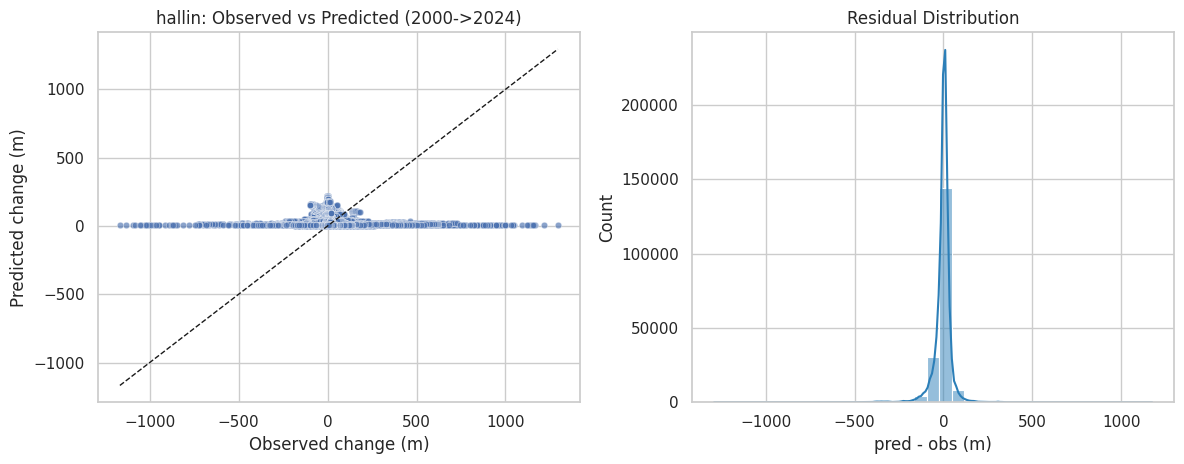

In [26]:
if best_eq is None:
    raise ValueError("No equation metrics available to plot.")

plot_df = data[data["equation"] == best_eq].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(data=plot_df, x="obs_valid_m_used", y="pred_valid_m", ax=axes[0], s=22, alpha=0.65)
lims = [
    np.nanmin([plot_df["obs_valid_m_used"].min(), plot_df["pred_valid_m"].min()]),
    np.nanmax([plot_df["obs_valid_m_used"].max(), plot_df["pred_valid_m"].max()]),
]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_title(f"{best_eq}: Observed vs Predicted (2000->2024)")
axes[0].set_xlabel("Observed change (m)")
axes[0].set_ylabel("Predicted change (m)")

sns.histplot(plot_df["resid_valid_m"], bins=35, kde=True, ax=axes[1], color="#2C7FB8")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("pred - obs (m)")

plt.tight_layout()
plt.show()

## 7. Compare All Equations Side by Side

/tmp/ipykernel_1461999/370726074.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_by_eq, x="equation", y="rmse_m", palette="deep")


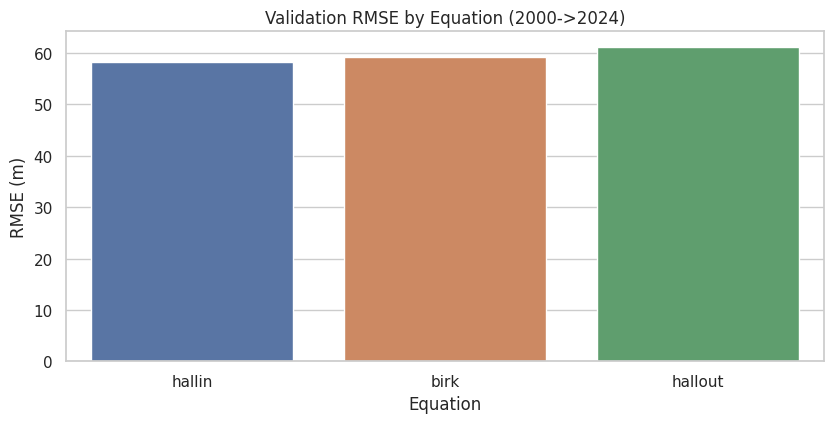

In [27]:
if len(metrics_by_eq) == 0:
    print("No equation rows available for comparison.")
else:
    plt.figure(figsize=(8.5, 4.4))
    sns.barplot(data=metrics_by_eq, x="equation", y="rmse_m", palette="deep")
    plt.title("Validation RMSE by Equation (2000->2024)")
    plt.xlabel("Equation")
    plt.ylabel("RMSE (m)")
    plt.tight_layout()
    plt.show()

## 8. Export Validation Outputs

In [28]:
obs_out = OUTPUT_DIR / "nzccd_observed_pre2000_post2000_targets.csv"
params_out = OUTPUT_DIR / "bruun_parameters_with_slr2020.csv"
rows_out = OUTPUT_DIR / "bruun_validation_rows_pre2000_to_2024.csv"
metrics_out = OUTPUT_DIR / "bruun_validation_metrics_by_equation.csv"
metrics_train_out = OUTPUT_DIR / "bruun_training_metrics_by_equation.csv"

obs.to_csv(obs_out, index=False)
bruun.to_csv(params_out, index=False)
data.to_csv(rows_out, index=False)
metrics_by_eq.to_csv(metrics_out, index=False)
metrics_train_by_eq.to_csv(metrics_train_out, index=False)

# Save one summary scatter for the winning equation
fig_path = None
if best_eq is not None:
    p = data[data["equation"] == best_eq].copy()
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(data=p, x="obs_valid_m_used", y="pred_valid_m", ax=ax, s=22, alpha=0.65)
    lims = [
        np.nanmin([p["obs_valid_m_used"].min(), p["pred_valid_m"].min()]),
        np.nanmax([p["obs_valid_m_used"].max(), p["pred_valid_m"].max()]),
    ]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_title(f"Best Equation: {best_eq}")
    ax.set_xlabel("Observed 2000->2024 change (m)")
    ax.set_ylabel("Predicted 2000->2024 change (m)")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "best_equation_obs_vs_pred_2000_2024.png"
    fig.savefig(fig_path, dpi=220)
    plt.close(fig)

print("Export complete:")
print("-", obs_out)
print("-", params_out)
print("-", rows_out)
print("-", metrics_out)
print("-", metrics_train_out)
if fig_path is not None:
    print("-", fig_path)

Export complete:
- /mnt/Bruunrule_Yaxiong/code/output/validation/nzccd_observed_pre2000_post2000_targets.csv
- /mnt/Bruunrule_Yaxiong/code/output/validation/bruun_parameters_with_slr2020.csv
- /mnt/Bruunrule_Yaxiong/code/output/validation/bruun_validation_rows_pre2000_to_2024.csv
- /mnt/Bruunrule_Yaxiong/code/output/validation/bruun_validation_metrics_by_equation.csv
- /mnt/Bruunrule_Yaxiong/code/output/validation/bruun_training_metrics_by_equation.csv
- /mnt/Bruunrule_Yaxiong/code/output/validation/best_equation_obs_vs_pred_2000_2024.png
